In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

C:\Users\Denis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("WorldCupMatches.csv")

In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 852 entries, 0 to 851
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  852 non-null    int64  
 1   Datetime              852 non-null    str    
 2   Stage                 852 non-null    str    
 3   Stadium               852 non-null    str    
 4   City                  852 non-null    str    
 5   Home Team Name        852 non-null    str    
 6   Home Team Goals       852 non-null    int64  
 7   Away Team Goals       852 non-null    int64  
 8   Away Team Name        852 non-null    str    
 9   Win conditions        852 non-null    str    
 10  Attendance            850 non-null    float64
 11  Half-time Home Goals  852 non-null    int64  
 12  Half-time Away Goals  852 non-null    int64  
 13  Referee               852 non-null    str    
 14  Assistant 1           852 non-null    str    
 15  Assistant 2           852 non-null

,Year,Home Team Goals,Away Team Goals,Attendance,Half-time Home Goals,Half-time Away Goals,RoundID,MatchID
count,852.000000,852.000000,852.000000,850.000000,852.000000,852.000000,8.520000e+02,8.520000e+02
mean,1985.089202,1.811033,1.022300,45164.800000,0.708920,0.428404,1.066177e+07,6.134687e+07
std,22.448825,1.610255,1.087573,23485.249247,0.937414,0.691252,2.729613e+07,1.110572e+08
min,1930.000000,0.000000,0.000000,2000.000000,0.000000,0.000000,2.010000e+02,2.500000e+01
25%,1970.000000,1.000000,0.000000,30000.000000,0.000000,0.000000,2.620000e+02,1.188750e+03
50%,1990.000000,2.000000,1.000000,41579.500000,0.000000,0.000000,3.370000e+02,2.191000e+03
75%,2002.000000,3.000000,2.000000,61374.500000,1.000000,1.000000,2.497220e+05,4.395006e+07
max,2014.000000,10.000000,7.000000,173850.000000,6.000000,5.000000,9.741060e+07,3.001865e+08


In [4]:
df.isnull().values.any()

np.True_

In [5]:
df[df.isnull().any(axis=1)]

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
823,2014,2014-06-30 17:00:00,Round of 16,Estadio Beira-Rio,Porto Alegre,Germany,2,1,Algeria,Germany win after extra time,NaN,0,0,RICCI Sandro (BRA),DE CARVALHO Emerson (BRA),VAN GASSE Marcelo (BRA),255951,300186460,GER,ALG
841,2014,2014-06-30 17:00:00,Round of 16,Estadio Beira-Rio,Porto Alegre,Germany,2,1,Algeria,Germany win after extra time,NaN,0,0,RICCI Sandro (BRA),DE CARVALHO Emerson (BRA),VAN GASSE Marcelo (BRA),255951,300186460,GER,ALG


In [6]:
df = df.dropna()
df.isnull().values.any()

np.False_

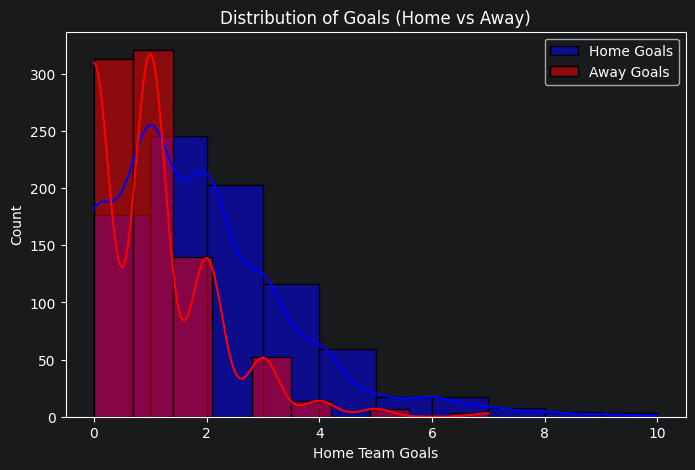

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Home Team Goals'], color='blue', label='Home Goals', kde=True, bins=10)
sns.histplot(df['Away Team Goals'], color='red', label='Away Goals', kde=True, bins=10)
plt.title("Distribution of Goals (Home vs Away)")
plt.legend()
plt.show()

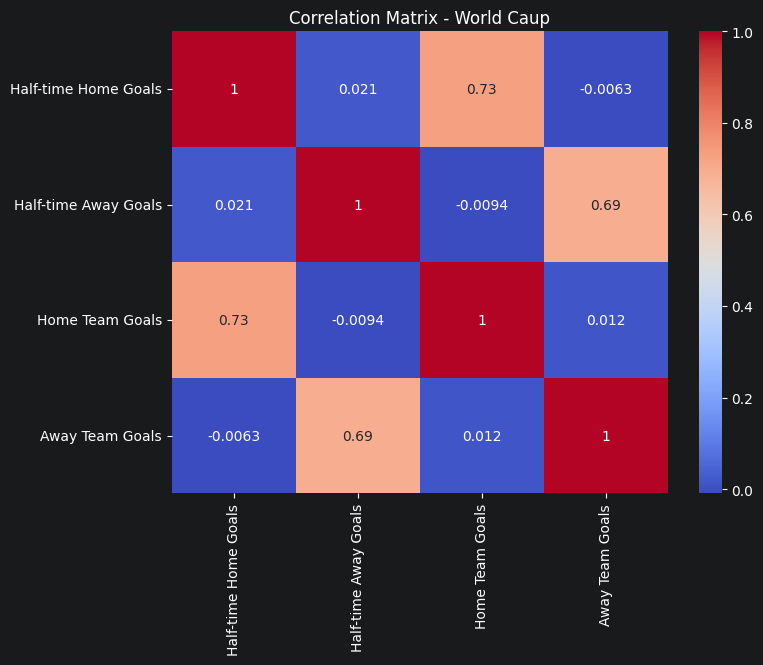

In [8]:
corr = df[['Half-time Home Goals', 'Half-time Away Goals', 'Home Team Goals', 'Away Team Goals']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix - World Caup")
plt.show()

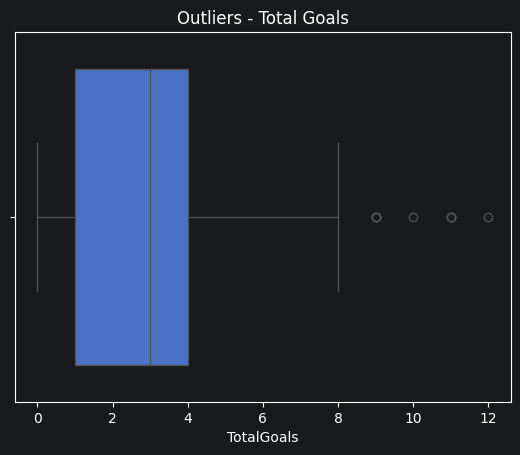

In [9]:
df['TotalGoals'] = df['Home Team Goals'] + df['Away Team Goals']
sns.boxplot(x=df['TotalGoals'])
plt.title("Outliers - Total Goals")
plt.show()

In [10]:
def get_result(row):
    if row['Home Team Goals'] > row['Away Team Goals']:
        return 2
    elif row['Home Team Goals'] < row['Away Team Goals']:
        return 0
    else:
        return 1
df['Result'] = df.apply(get_result, axis=1)

In [11]:
df = df.sort_values('Year')
h2h_stats = {}
h2h_home_wins = []
h2h_away_wins = []
h2h_draws = []
for _, row in df.iterrows():
    team1 = row['Home Team Name']
    team2 = row['Away Team Name']
    key = (team1, team2)
    reverse_key = (team2, team1)
    wins1 = h2h_stats.get(key, {}).get('wins', 0)
    wins2 = h2h_stats.get(reverse_key, {}).get('wins', 0)
    draws = h2h_stats.get(key, {}).get('draws', 0)
    h2h_home_wins.append(wins1)
    h2h_away_wins.append(wins2)
    h2h_draws.append(draws)
    if row['Home Team Goals'] > row['Away Team Goals']:
        h2h_stats.setdefault(key, {'wins':0, 'draws':0})
        h2h_stats[key]['wins'] += 1
    elif row['Home Team Goals'] < row['Away Team Goals']:
        h2h_stats.setdefault(reverse_key, {'wins':0, 'draws':0})
        h2h_stats[reverse_key]['wins'] += 1
    else:
        h2h_stats.setdefault(key, {'wins':0, 'draws':0})
        h2h_stats[key]['draws'] += 1
df['h2h_home_wins'] = h2h_home_wins
df['h2h_away_wins'] = h2h_away_wins
df['h2h_draws'] = h2h_draws

In [12]:
X = df.drop(columns=[
    'Result',
    'Home Team Goals',
    'Away Team Goals',
    'Half-time Home Goals',
    'Half-time Away Goals'
])
y = df['Result']
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [ ]:
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}
classes = sorted(y.unique())
results = []
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for idx, (name, model) in enumerate(models.items()):
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
    else:
        y_prob = None
    if y_prob is not None:
        y_test_bin = label_binarize(y_test, classes=classes)
        roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='weighted')
    else:
        roc_auc = float('nan')
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1": f1_score(y_test, y_pred, average='weighted'),
        "ROC-AUC": roc_auc
    })
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt="d", ax=axes[idx],
                xticklabels=classes, yticklabels=classes,
                cmap="Blues", cbar=False)
    axes[idx].set_title(f"{name}", fontsize=10)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")
plt.suptitle("Confusion Matrices - Baseline Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Training Naive Bayes...

Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training SVM...

Training KNN...


In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print("\nToate modelele baseline:")
print(results_df.to_markdown(index=False))
print("\nTop 5 modele:")
print(results_df.head(5).to_markdown(index=False))

In [ ]:
NEEDS_SCALING = {"SVM", "KNN", "LogReg"}
tuning_configs = {
    "LogReg": (
        LogisticRegression(max_iter=1000),
        {'model__C': [0.1, 1, 10]}
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, None]
        }
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(),
        {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1]
        }
    ),
    "SVM": (
        SVC(probability=True),
        {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['linear', 'rbf']
        }
    ),
    "KNN": (
        KNeighborsClassifier(),
        {
            'model__n_neighbors': [3, 5, 7, 11]
        }
    )
}
results = []
best_estimators = {}
for name, (model_instance, params) in tuning_configs.items():
    print(f"Optimizing {name}...")
    if name in NEEDS_SCALING:
        estimator = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model_instance)
        ])
    else:
        estimator = model_instance
    grid = GridSearchCV(
        estimator,
        params,
        cv=3,
        scoring='f1_weighted',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    best_estimators[name] = best_model
    y_pred = best_model.predict(X_test)
    print(f"  Best params: {grid.best_params_}")
    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred, average='weighted')
    })
results_df_tuned = pd.DataFrame(results).sort_values("F1", ascending=False)
print(results_df_tuned[["Model", "Accuracy", "F1"]].to_markdown(index=False))

In [ ]:
best_tuned_name = results_df_tuned.iloc[0]["Model"]
best_tuned_model = best_estimators[best_tuned_name]
y_pred_best = best_tuned_model.predict(X_test)
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_best, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Away Win (0)", "Draw (1)", "Home Win (2)"],
    yticklabels=["Away Win (0)", "Draw (1)", "Home Win (2)"],
    cmap="Blues"
)
plt.title(f"Confusion Matrix - {best_tuned_name} (tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(15, 20))
for i, (name, model) in enumerate(best_estimators.items(), 1):
    plt.subplot(5, 1, i)
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=3,
        scoring='f1_weighted',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
    plt.title(f"Learning Curve: {name}")
    plt.xlabel("Training Examples")
    plt.ylabel("F1 Score")
    plt.legend(loc="best")
    plt.grid(True)
plt.tight_layout()
plt.show()